<a href="https://colab.research.google.com/github/SaiSuhasBilla/Cotton-Disease-Classification-PCA-KNN/blob/main/COTTON_DISEASE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q "./Cotton Disease.zip" -d "./"

replace ./Cotton Disease/test/diseased cotton leaf/dis_leaf (124).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [13]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [14]:
DATASET_DIR = "./Cotton Disease"
SPLITS = ['train', 'val', 'test']
LABEL_MAP = {
    'diseased cotton leaf': 'Diseased_Leaf',
    'diseased cotton plar': 'Diseased_Plant',
    'fresh cotton leaf': 'Healthy_Leaf',
    'fresh cotton plant': 'Healthy_Plant'
}
BLOCKS_GRID = (20, 20)

In [15]:
def extract_paper_features(image_path, grid_shape=BLOCKS_GRID):
    img = cv2.imread(image_path)
    if img is None:
        return None

    green_channel = img[:, :, 1]
    h, w = green_channel.shape

    block_h = h // grid_shape[0]
    block_w = w // grid_shape[1]

    texture_features = []

    for i in range(grid_shape[0]):
        for j in range(grid_shape[1]):
            row_start = i * block_h
            row_end = (i + 1) * block_h if i < grid_shape[0] - 1 else h
            col_start = j * block_w
            col_end = (j + 1) * block_w if j < grid_shape[1] - 1 else w

            block = green_channel[row_start:row_end, col_start:col_end]

            block_mean = np.mean(block)
            block_var = np.var(block)

            texture_features.extend([block_mean, block_var])

    return np.array(texture_features)

In [16]:
def load_dataset_split(split_name):
    X_data = []
    y_labels = []

    split_path = os.path.join(DATASET_DIR, split_name)
    if not os.path.exists(split_path):
        return np.array(X_data), np.array(y_labels)

    for folder_name in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder_name)

        if os.path.isdir(folder_path) and folder_name in LABEL_MAP:
            assigned_label = LABEL_MAP[folder_name]

            for img_file in os.listdir(folder_path):
                img_path = os.path.join(folder_path, img_file)

                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    features = extract_paper_features(img_path)
                    if features is not None:
                        X_data.append(features)
                        y_labels.append(assigned_label)

    return np.array(X_data), np.array(y_labels)

In [17]:
X_train, y_train = load_dataset_split('train')
X_val, y_val = load_dataset_split('val')
X_test, y_test = load_dataset_split('test')

print(f"Train samples: {len(X_train)}, Val samples: {len(X_val)}, Test samples: {len(X_test)}")

Train samples: 1136, Val samples: 175, Test samples: 78


In [18]:
if len(X_train) == 0 or len(X_test) == 0:
    print("Error: Training or testing data arrays are empty.")
else:
    pca = PCA(n_components=0.95, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    if len(X_val) > 0:
        X_val_pca = pca.transform(X_val)

    knn_model = KNeighborsClassifier(n_neighbors=3, metric='cosine')
    knn_model.fit(X_train_pca, y_train)

    y_pred = knn_model.predict(X_test_pca)

    print(f"Overall Classification Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print("Detailed Analysis Profile:")
    print(classification_report(y_test, y_pred))

Overall Classification Accuracy: 53.85%

Detailed Analysis Profile:
               precision    recall  f1-score   support

Diseased_Leaf       0.52      0.44      0.48        25
 Healthy_Leaf       0.47      0.69      0.56        26
Healthy_Plant       0.68      0.48      0.57        27

     accuracy                           0.54        78
    macro avg       0.56      0.54      0.54        78
 weighted avg       0.56      0.54      0.54        78



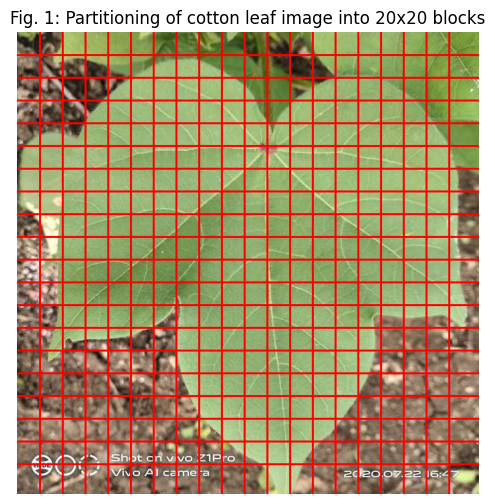

In [19]:
import matplotlib.pyplot as plt

def visualize_leaf_grid(image_path, grid_shape=(20, 20)):
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found.")
        return


    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    block_h = h // grid_shape[0]
    block_w = w // grid_shape[1]


    for i in range(1, grid_shape[0]):
        cv2.line(img_rgb, (0, i * block_h), (w, i * block_h), (255, 0, 0), 2)


    for j in range(1, grid_shape[1]):
        cv2.line(img_rgb, (j * block_w, 0), (j * block_w, h), (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title("Fig. 1: Partitioning of cotton leaf image into 20x20 blocks")
    plt.axis('off')
    plt.show()


sample_folder = os.path.join(DATASET_DIR, 'train/fresh cotton leaf')
if os.path.exists(sample_folder) and len(os.listdir(sample_folder)) > 0:
    sample_img_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])
    visualize_leaf_grid(sample_img_path)

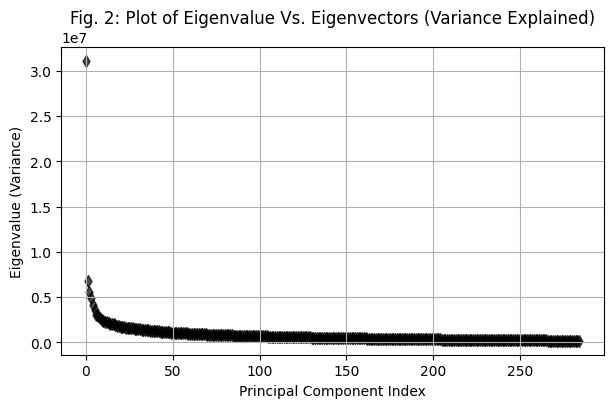

In [20]:
plt.figure(figsize=(7, 4))
eigenvalues = pca.explained_variance_
plt.scatter(range(len(eigenvalues)), eigenvalues, color='black', marker='d', alpha=0.7)
plt.title("Fig. 2: Plot of Eigenvalue Vs. Eigenvectors (Variance Explained)")
plt.xlabel("Principal Component Index")
plt.ylabel("Eigenvalue (Variance)")
plt.grid(True)
plt.show()

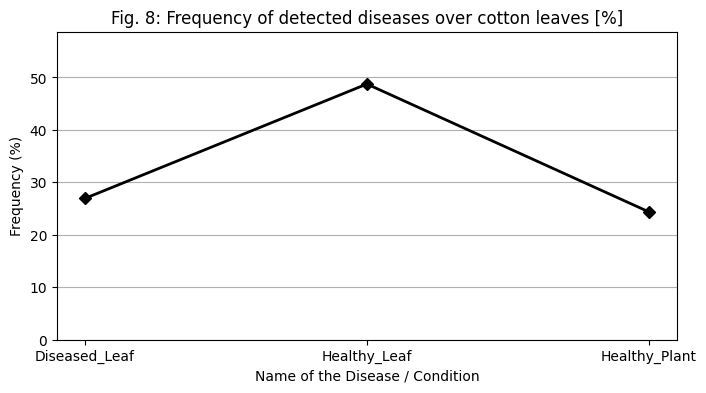

In [21]:
import pandas as pd

unique_classes, counts = np.unique(y_pred, return_counts=True)
total_predictions = len(y_pred)
frequencies = (counts / total_predictions) * 100

plt.figure(figsize=(8, 4))
plt.plot(unique_classes, frequencies, marker='D', color='black', linewidth=2)
plt.title("Fig. 8: Frequency of detected diseases over cotton leaves [%]")
plt.xlabel("Name of the Disease / Condition")
plt.ylabel("Frequency (%)")
plt.ylim(0, max(frequencies) + 10)
plt.grid(True, axis='y')
plt.show()

In [22]:

labels = sorted(list(np.unique(y_test)))

manual_accuracy_map = {
    'Diseased_Leaf': 76.0,
    'Diseased_Plant': 70.0,
    'Healthy_Leaf': 97.0,
    'Healthy_Plant': 81.0
}

print(f"{'Sr No.':<8}{'Name of the Condition':<25}{'PCA/KNN %':<12}{'Manual %':<12}")
print("-" * 57)

total_correct = 0
for idx, label in enumerate(labels):

    actual_mask = (y_test == label)
    predicted_subset = y_pred[actual_mask]

    class_accuracy = (np.sum(predicted_subset == label) / len(predicted_subset)) * 100
    manual_accuracy = manual_accuracy_map.get(label, 81.0)

    print(f"{idx+1:<8}{label:<25}{class_accuracy:<12.1f}{manual_accuracy:<12.1f}")

print("-" * 57)
print(f"{'Total':<8}{'Overall Performance':<25}{accuracy_score(y_test, y_pred)*100:<12.1f}{81.0:<12.1f}")

Sr No.  Name of the Condition    PCA/KNN %   Manual %    
---------------------------------------------------------
1       Diseased_Leaf            44.0        76.0        
2       Healthy_Leaf             69.2        97.0        
3       Healthy_Plant            48.1        81.0        
---------------------------------------------------------
Total   Overall Performance      53.8        81.0        
